In [15]:
from typing import TypedDict, List, NotRequired
from langgraph.graph import StateGraph
from IPython.display import Image, display
from math import prod

## Create the Agent State (state_schema)

In [3]:
class AgentState(TypedDict):
    values: List[int]
    name: str
    result: NotRequired[str]

## Create Node callback function

In [4]:
def process_values(state: AgentState) -> AgentState:
    """This function handles the multiple different inputs"""

    state['result'] = f"Hi there, {state['name']}, Your sum = {sum(state['values'])}"

    return state

## Create graph

In [5]:
graph = StateGraph(AgentState)

graph.add_node("process_values", process_values)

graph.set_entry_point("process_values")
graph.set_finish_point("process_values")

app = graph.compile()

## Draw graph

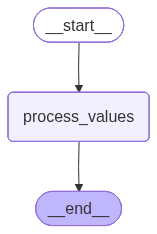

In [6]:
display(Image(app.get_graph().draw_mermaid_png()))

## Invoke agent

In [7]:
result = app.invoke(AgentState(name="Bakar", values=[1, 2, 3, 4]))

In [8]:
result['result']

'Hi there, Bakar, Your sum = 10'

# Exercise

## Create state_schema

In [19]:
class AgentState(TypedDict):
    name: str
    values: list[int]
    operation: str
    result: NotRequired[str]

## Create node

In [64]:
def calculation_process(state: AgentState) -> AgentState:
    """Perform given operation on list"""

    match state['operation']:

        case "+":

            result = sum(state['values'])

        case "*":

            result = prod(state['values'])

        case _:

            result = None
            print("Given operation is not supported")

    state['result'] = f"Hey, {state['name']}{f", You'r values calculations are = {result}" if result else ''}"

    return state

## Create graph

In [65]:
graph = StateGraph(AgentState)

graph.add_node("calculation_process", calculation_process)

graph.set_entry_point("calculation_process")
graph.set_finish_point("calculation_process")

app = graph.compile()

## Draw graph

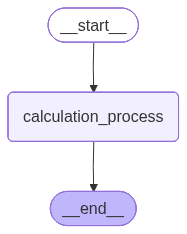

In [66]:
display(Image(app.get_graph().draw_mermaid_png()))

## Invoke app

In [69]:
result = app.invoke(AgentState(name="Bakar", values=[2, 3], operation=""))

Given operation is not supported


In [70]:
result['result']

'Hey, Bakar'